<a href="https://colab.research.google.com/github/GabCAD92/Machine-learning-tasks/blob/main/Gabriel_Owolabi_Lecture_10_Decision_Trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Machine Learning
## Supervised Learning: Decision Trees practice

This lesson implements __Decision Trees__, __Ensemble Learning__ and __Random Forest__ focusing on a __classification__ task.


### Professor:

<img src="https://www.sorocaba.unesp.br/Home/Graduacao/EngenhariadeControleeAutomacao/alexandre/alex_marta1_small.jpg" width="100" style="float: left; margin-right: 5px;" border="10px" />

  __Prof. Dr. Alexandre da Silva Simões__ <br>
  Control and Automation Engineering Department (DECA) <br>
  Institute of Science and Technology<br>
  São Paulo State University (Unesp) <br>
  Campus Sorocaba <br>
  www.sorocaba.unesp.br/professor/assimoes

<br/>

References:
* Scikit learn: Plot the decision surface of decision trees trained on the iris dataset. https://scikit-learn.org/stable/auto_examples/tree/plot_iris_dtc.html
* Scikit-learn: DecisionBoundaryDisplay. https://scikit-learn.org/stable/modules/generated/sklearn.inspection.DecisionBoundaryDisplay.html
* Medium: Stacking -Ensemble meta Algorithms for improve predictions. https://medium.com/ml-research-lab/stacking-ensemble-meta-algorithms-for-improve-predictions-f4b4cf3b9237


____

# Table of Contents


1. Dataset <br>
  1.1. Loading the Iris Dataset <br>
2. Decision Trees <br>
	2.1. Preliminary tests: classification using 2 features <br>
	&nbsp; &nbsp; &nbsp; 2.1.1. Decision Boundary <br>
	&nbsp; &nbsp; &nbsp; 2.1.2. Decision Rules <br>
	&nbsp; &nbsp; &nbsp; 2.1.3. Changing Tree Depth <br>
 2.2. Classification using all features <br>
 &nbsp; &nbsp; &nbsp; 2.2.1. Decision Rules <br>
 &nbsp; &nbsp; &nbsp; 2.2.2. Limiting tree depth <br>
 &nbsp; &nbsp; &nbsp; 2.2.3. ID3 Algorithm <br>
3. Randon Forest <br>
4. Ensemble Learning <br>

____

# 1. Introduction

## 1.1. Loading the Iris Dataset

First of all, let's load the Iris Dataset...

In [1]:
# Import Iris dataset
from sklearn.datasets import load_iris
iris = load_iris()


The Iris dataset has:

*   3 output classes (setosa, versicolor, virginica)
*   50 examples of each class (150 total examples)
*   4 features (sepal lenght, sepal width, petal lenght, petal width) in cm

<center>
<img src="https://drive.google.com/thumbnail?id=1IpBVgolS9COYB6DdMHLK7efhnVAYznh-" width="250" style="display: block; margin: auto;" border="1px" />
</center>



# 2. Decision Trees

##2.1. Preliminary tests: classification using 2 features

Now let's classify our data using Decision Trees.
Considering that we have a 4-features (f0, f1, f2, f3) problem, in order to see our classification in 2D, let's initially create 6 (six) distinct Decision Trees, one for each combination of 2 features (f0-f1, f0-f2, f0-f3, f1-f2, f1-f3, f2-f3).

###2.1.1. Decision Boundary

Let's plot the __decision boundaries__ for the selected tree.


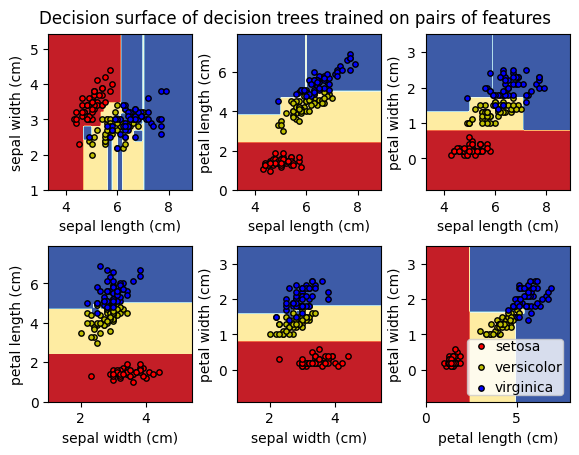

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_iris
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.tree import DecisionTreeClassifier

# Parameters
n_classes = 3
plot_colors = "ryb"
plot_step = 0.02

for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3]]):
    # We only take the two corresponding features
    X = iris.data[:, pair]
    y = iris.target

    # Train
    clf = DecisionTreeClassifier().fit(X, y)

    # Plot the decision boundary
    ax = plt.subplot(2, 3, pairidx + 1)
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)
    DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        cmap=plt.cm.RdYlBu,
        response_method="predict",
        ax=ax,
        xlabel=iris.feature_names[pair[0]],
        ylabel=iris.feature_names[pair[1]],
    )

    # Plot the training points
    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y == i)
        plt.scatter(
            X[idx, 0],
            X[idx, 1],
            c=color,
            label=iris.target_names[i],
            edgecolor="black",
            s=15,
        )

plt.suptitle("Decision surface of decision trees trained on pairs of features")
plt.legend(loc="lower right", borderpad=0, handletextpad=0)
_ = plt.axis("tight")



First of all, we will focus in only one 2-features tree: "sepal width" x "sepal length"...

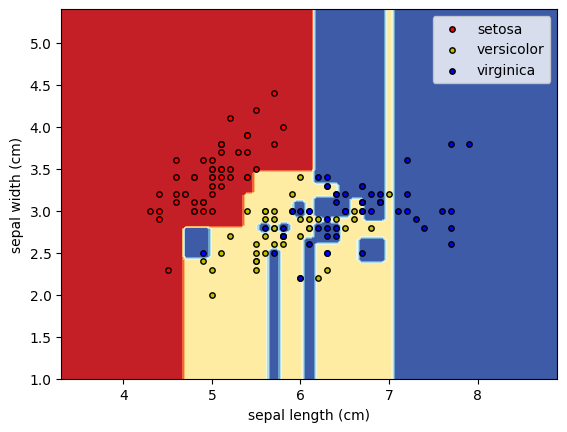

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.tree import DecisionTreeClassifier

#Setup
f1 = 0;  # 1st selected feature (from 0 to 3)
f2 = 1;  # 2nd selected feature (from 0 to 3)
plot_colors = "ryb"
n_classes = 3

X = iris.data[:, [f1, f2]]
feature_1, feature_2 = np.meshgrid(
    np.linspace(iris.data[:, f1].min(), iris.data[:, f1].max()),
    np.linspace(iris.data[:, f2].min(), iris.data[:, f2].max())
)
grid = np.vstack([feature_1.ravel(), feature_2.ravel()]).T

# Training and prediction
tree = DecisionTreeClassifier().fit(iris.data[:, [f1,f2]], iris.target)
y_pred = np.reshape(tree.predict(grid), feature_1.shape)

# Plot the decision boundary
DecisionBoundaryDisplay.from_estimator(
  tree,
  X,
  cmap=plt.cm.RdYlBu,
  response_method="predict",
  xlabel=iris.feature_names[f1],
  ylabel=iris.feature_names[f2],
)

# Plot the training points
for i, color in zip(range(n_classes), plot_colors):
  idx = np.where(y == i)
  plt.scatter(
    X[idx, 0],
    X[idx, 1],
    c=color,
    label=iris.target_names[i],
    edgecolor="black",
    s=15,
  )

plt.legend()
plt.show()

### 2.1.2. Decision Rules

Let's see the __Decision Rules__ for this 2-feature tree...

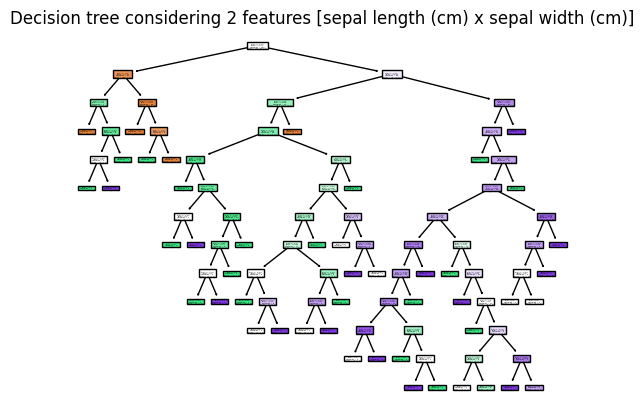

In [4]:
from sklearn.tree import plot_tree

plt.figure()
plot_tree(tree, filled=True)
plt.title("Decision tree considering 2 features [" + iris.feature_names[f1] + " x " + iris.feature_names[f2] + "]")
plt.show()

It is important to notice that, by default, Decision Tree Classifier in Scikit-learn adopts:
 *  CART algorithm (based on GINI)
 *  Unlimited tree depth

### 2.1.3. Changing Tree Depth

Now let's check the result when we __limit the tree depth to 2__...

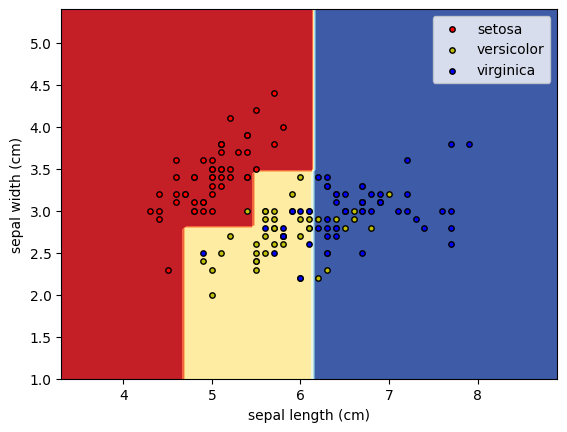

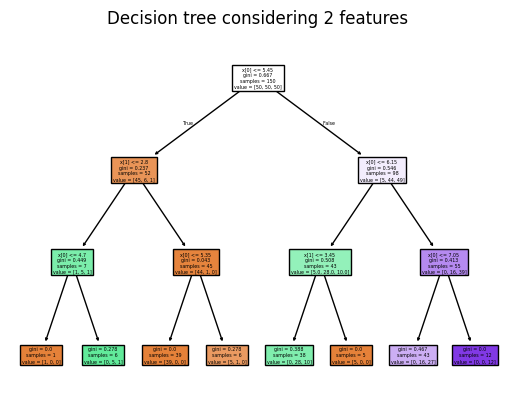

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.tree import DecisionTreeClassifier

#Setup
f1 = 0;  # 1st selected feature (from 0 to 3)
f2 = 1;  # 2nd selected feature (from 0 to 3)
tree_depth = 3
plot_colors = "ryb"
n_classes = 3

X = iris.data[:, [f1, f2]]
feature_1, feature_2 = np.meshgrid(
    np.linspace(iris.data[:, f1].min(), iris.data[:, f1].max()),
    np.linspace(iris.data[:, f2].min(), iris.data[:, f2].max())
)
grid = np.vstack([feature_1.ravel(), feature_2.ravel()]).T

# Training and prediction
tree = DecisionTreeClassifier(max_depth = tree_depth).fit(iris.data[:, [f1,f2]], iris.target)
y_pred = np.reshape(tree.predict(grid), feature_1.shape)

# Plot the decision boundary
DecisionBoundaryDisplay.from_estimator(
  tree,
  X,
  cmap=plt.cm.RdYlBu,
  response_method="predict",
  xlabel=iris.feature_names[f1],
  ylabel=iris.feature_names[f2],
)

# Plot the training points
for i, color in zip(range(n_classes), plot_colors):
  idx = np.where(y == i)
  plt.scatter(
    X[idx, 0],
    X[idx, 1],
    c=color,
    label=iris.target_names[i],
    edgecolor="black",
    s=15,
  )

plt.legend()
plt.show()

# Display rules
plt.figure()
plot_tree(tree, filled=True)
plt.title("Decision tree considering 2 features")
plt.show()

## 2.2 Classification using all features

Not let's use all (4) available features of our dataset. <br>
Of course, we are no longer able to visualize the decision boundaries in a 4-D space, except by rules... <br>
In order to evaluate our classifier, let's split our data into __trainning__ and __test__ sets...

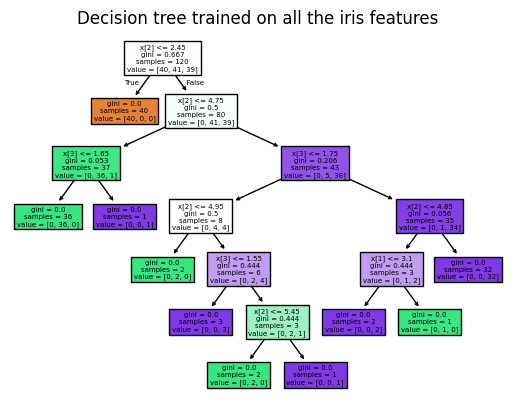

In [6]:
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

tree_depth = None

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a decision tree classifier
tree = DecisionTreeClassifier(max_depth = tree_depth)

# Train the model on the training data
tree.fit(X_train, y_train)

# Make predictions on the test data
y_pred = tree.predict(X_test)

# Plot
plt.figure()
plot_tree(tree, filled=True)
plt.title("Decision tree trained on all the iris features")
plt.show()


Let's evaluete systems accuracy...

In [7]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 100.00%


### 2.2.2. Limiting tree depth

Now let's check the system accuracy with max_depth = 2...

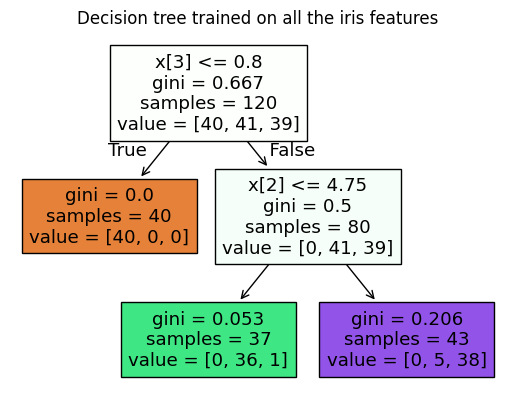

Accuracy: 96.67%


In [8]:
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

tree_depth = 2

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a decision tree classifier
tree = DecisionTreeClassifier(max_depth = tree_depth)

# Train the model on the training data
tree.fit(X_train, y_train)

# Make predictions on the test data
y_pred = tree.predict(X_test)

# Plot
plt.figure()
plot_tree(tree, filled=True)
plt.title("Decision tree trained on all the iris features")
plt.show()

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")

### 2.2.3. ID3 Algorithm





Now let's learn how to change the __cost function__ from "*gini*" to "*entropy*", that is, let's use __ID3 algorithm__ instead of __CART__!


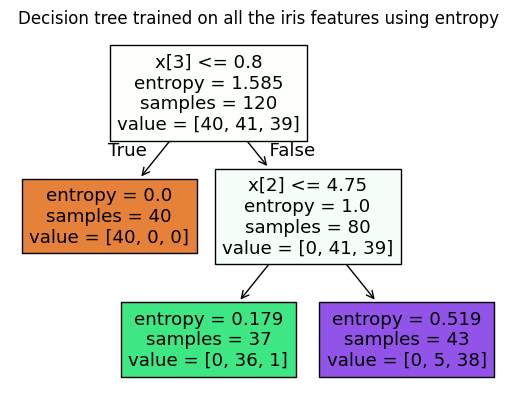

Accuracy: 96.67%


In [9]:
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

tree_depth = 2
crit = "entropy" # "entropy" or "gini"

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a decision tree classifier
tree = DecisionTreeClassifier(max_depth = tree_depth, criterion=crit)

# Train the model on the training data
tree.fit(X_train, y_train)

# Make predictions on the test data
y_pred = tree.predict(X_test)

# Plot
plt.figure()
plot_tree(tree, filled=True)
plt.title("Decision tree trained on all the iris features using " + crit)
plt.show()

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")

## 3. Random Forest

In [10]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create forest
rnd_clf = RandomForestClassifier(n_estimators=5000, n_jobs=-1)
rnd_clf.fit(X_train, y_train)

# Make predictions on the test data
y_pred = tree.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")

# Display most important features...
for name, score in zip(iris["feature_names"], rnd_clf.feature_importances_):
  print(name, score)

Accuracy: 96.67%
sepal length (cm) 0.09884359487464786
sepal width (cm) 0.030120098656903644
petal length (cm) 0.445679387127009
petal width (cm) 0.4253569193414394


# 4. Ensemble Learning

Now let's check the performance of __trhee__ distinct classifiers...

In [11]:
from sklearn import datasets
import numpy as np

#Import	Random	forest	Logistic	regression,	naive	bayes	and	knn	classifier classes	for	creating	stacking
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Load Iris dataset
iris = datasets.load_iris()

# Extract data and target out of dataset
X, y = iris.data[:, 1:3], iris.target

# We will define a method to calculate accuracy of prericted output
def CalculateAccuracy(y_test, pred_label):
    nnz = np.shape(y_test)[0] - np.count_nonzero(pred_label - y_test)
    acc = 100*nnz / float(np.shape(y_test)[0])
    return acc

clf1 = KNeighborsClassifier(n_neighbors=2) # Create KNN
clf2 = RandomForestClassifier(n_estimators=2, random_state=1) #Create Random Forest
clf3 = GaussianNB() #Create Naive Bayes
lr = LogisticRegression() #Create Logistic Regression

# Train classifiers
clf1.fit(X,	y)
clf2.fit(X,	y)
clf3.fit(X,	y)

# Predict outputs
f1 = clf1.predict(X)
acc1 = CalculateAccuracy(y,	f1)
print("accuracy from KNN: "+str(acc1))

f2 = clf2.predict(X)
acc2 = CalculateAccuracy(y,	f2)
print("accuracy from Random Forest: "+str(acc2))

f3 = clf3.predict(X)
acc3 = CalculateAccuracy(y,	f3)
print("accuracy from Naive Bayes: "+str(acc3))

#Combine	the	predictions	into	a	single	array	and	transpose	the	array	to	match	input	shape	of	or	classifier.
f = [f1, f2, f3]
f = np.transpose(f)

#Now train the classifier
lr.fit(f, y)
final = lr.predict(f)

#Calculate	and	print	the	accuracy of	final	classifier
acc4 = CalculateAccuracy(y, final)
print("\naccuracy from Stacking:"+str(acc4))

accuracy from KNN: 96.0
accuracy from Random Forest: 94.66666666666667
accuracy from Naive Bayes: 92.0

accuracy from Stacking:96.66666666666667


____

<center>
<img src="https://upload.wikimedia.org/wikipedia/commons/0/0a/Logo_Unesp.svg" width="400" style="float: left; margin-right: 5px;" border="0px" />
</center>